# AG_PRAXIS NB08 — Evaluation and Significance

This notebook does two things, and they are separate jobs that happen to need the same
model and the same test partition.

The first is to find out how much traffic has to be observed before each attack class
becomes identifiable. Every result in this project so far has given the model a window of
fifty records and asked what class it is. That answers whether a class can be detected at
all and says nothing about how early. Here the same model is trained four times on four
observation budgets, five records, ten, twenty-five and fifty, and the per-class scores
are read across them. A class that reaches its full score at five records is one a
detector could catch almost immediately. A class that has not reached a usable score by
fifty is one that needs more traffic than a window of this length carries.

The second is to find out how much of any difference already recorded is just the seed.
One run at one seed produces one number, and a difference between two such numbers means
nothing until the size of the run-to-run variation is known. Four more runs at the full
budget, with nothing changed but the seed, give that variation, and every difference
recorded elsewhere in this project can then be read against it.

The budgets are taken as prefixes of the windows that already exist. At budget k the model
sees records 0 to k of each fifty-record window and the rest are not shown to it. No
sequences are rebuilt, the window stays at fifty and the stride at twenty-five, and the
number of windows and which records fall in which window are identical at every budget. If
that were not true the budgets would be scored on different items and could not be
compared, so it is asserted rather than assumed.

Seven models are trained here. The eighth run this notebook reads, budget fifty at seed
42, already exists: it is the sequence run from earlier in this project, and it is loaded
from disk rather than trained again.


The data and the artifacts are on Drive and the code is in the repository, so the first
block mounts one and clones the other, and records the commit it is running from.


In [1]:
import subprocess
import sys
from datetime import date
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/AGREWAL14/AG_PRAXIS.git"
NOTEBOOK = "AG_PRAXIS_NB08_evaluation_and_significance.ipynb"

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    REPO_ROOT = Path("/content/repo")
    if REPO_ROOT.exists():
        subprocess.run(["git", "-C", str(REPO_ROOT), "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
else:
    REPO_ROOT = Path.cwd()
    while not (REPO_ROOT / "config" / "base.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
        REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def git(*args):
    return subprocess.run(
        ["git", "-C", str(REPO_ROOT), *args], capture_output=True, text=True
    ).stdout.strip()


GIT_SHA = git("rev-parse", "--short", "HEAD")
GIT_BRANCH = git("rev-parse", "--abbrev-ref", "HEAD")
GIT_DIRTY = bool(git("status", "--porcelain"))
RUN_DATE = date.today().isoformat()

print(f"colab     : {IN_COLAB}")
print(f"repo root : {REPO_ROOT}")
print(f"git sha   : {GIT_SHA} on {GIT_BRANCH}" + ("   WORKING TREE DIRTY" if GIT_DIRTY else ""))
print(f"run date  : {RUN_DATE}")


Mounted at /content/drive
colab     : True
repo root : /content/repo
git sha   : d193464 on main
run date  : 2026-08-10


The parameters come from `config/base.yaml` and the shape of the data comes from the
manifest the preprocessing step wrote. Neither is retyped here. What is written down in
this block is only what belongs to this notebook: the four budgets, the four new seeds,
the F1 level a class has to reach for the first analysis, and the two groups of classes
that analysis compares.

The groups are fixed by the benchmark's own taxonomy rather than by anything measured
here, which matters because a group defined after seeing the scores would make the
comparison circular. Recon-Ping_Sweep sits in neither group. Its 926 records give two
validation and four test sequences at this window and stride, and an F1 computed on four
items can take five values, so it cannot carry a per-class measurement. Its figures are
printed everywhere the others are, with that caveat attached.

Everything this notebook writes goes to its own directory on Drive. Nothing is written
into the cloned repository, because the clone disappears when the session ends.


In [2]:
import gc
import json
import time

import numpy as np
import pandas as pd

from src import inventory as inv
from src import runs as rn
from src import sequence as sq
from src import significance as sg

CFG = inv.load_config(REPO_ROOT)

SEED = CFG["seed"]
WINDOW = int(CFG["sequence"]["window"])
STRIDE = int(CFG["sequence"]["stride"])
BATCH_SIZE = int(CFG["training"]["batch_size"])
EPOCHS = int(CFG["training"]["epochs"])
ARTIFACTS = Path(CFG["paths"]["artifacts"])

NB04_DIR = ARTIFACTS / "NB04"
OUT_DIR = (ARTIFACTS / "NB08") if IN_COLAB else (REPO_ROOT / "results" / "NB08")
PARENT_RUN = "sequence_cnn_lstm_19class"

BUDGETS = (5, 10, 25, 50)
FULL_BUDGET = 50
NEW_SEEDS = (43, 44, 45, 46)
ALL_SEEDS = (SEED, *NEW_SEEDS)

F1_TARGET = 0.80
SATURATION_EPSILON = 0.02
ALPHA = 0.05
CODE_DTYPE = "int16"

VOLUMETRIC = (
    "DDoS-ICMP", "DDoS-SYN", "DDoS-TCP", "DDoS-UDP",
    "DoS-ICMP", "DoS-SYN", "DoS-TCP", "DoS-UDP",
)
LOW_RATE = (
    "Recon-OS_Scan", "Recon-Port_Scan", "Recon-VulScan", "Spoofing", "MQTT-Malformed_Data",
)
TOO_FEW_SEQUENCES = ("Recon-Ping_Sweep",)
THIN_BUT_KEPT = ("Recon-VulScan", "MQTT-Malformed_Data")

INTERVENTIONS = (
    "class_weighted_loss", "focal_loss", "logit_adjustment",
    "threshold_tuning", "window_resampling",
)

if IN_COLAB and not ARTIFACTS.exists():
    raise FileNotFoundError(
        f"{ARTIFACTS} does not exist. Drive is not mounted, or the artefacts path in "
        "config/base.yaml is wrong. Nothing this notebook writes would survive."
    )


def first_existing(candidates, what):
    found = next((Path(p) for p in candidates if Path(p).exists()), None)
    if found is None:
        raise FileNotFoundError(f"{what} not found. Looked in: {[str(p) for p in candidates]}")
    return found


MANIFEST_PATH = first_existing(
    [REPO_ROOT / "data" / "processed" / "NB04_manifest.json", NB04_DIR / "NB04_manifest.json"],
    "NB04_manifest.json",
)
MANIFEST = json.loads(MANIFEST_PATH.read_text())
if MANIFEST.get("is_fast_pass"):
    raise ValueError(f"{MANIFEST_PATH} came from a fast pass and is not a result")

FEATURES = list(MANIFEST["columns"]["kept"])
CLASSES = sorted(MANIFEST["arrays"]["sequences_train"]["by_class"])
SEQUENCES = {
    partition: dict(MANIFEST["arrays"][f"sequences_{partition}"]["by_class"])
    for partition in ("train", "val", "test")
}

named = set(VOLUMETRIC) | set(LOW_RATE) | set(TOO_FEW_SEQUENCES)
unplaced = sorted(set(CLASSES) - named)
if not named <= set(CLASSES):
    raise ValueError(f"a named class is not in the corpus: {sorted(named - set(CLASSES))}")

pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 90)

print(f"seed           : {SEED}, and {', '.join(str(s) for s in NEW_SEEDS)} for the repeats")
print(f"window, stride : {WINDOW} records, {STRIDE} records, unchanged by any budget")
print(f"batch, epochs  : {BATCH_SIZE}, {EPOCHS}")
print(f"budgets        : {', '.join(str(k) for k in BUDGETS)} records")
print(f"manifest       : {MANIFEST_PATH}")
print(f"  written by   : {MANIFEST['generated_by']} at {MANIFEST['git_sha']} on "
      f"{MANIFEST['generated_on']}")
print(f"features       : {len(FEATURES)}")
print(f"classes        : {len(CLASSES)}")
print(f"writing to     : {OUT_DIR}")
print()
print(f"volumetric ({len(VOLUMETRIC)}): {', '.join(VOLUMETRIC)}")
print(f"low-rate   ({len(LOW_RATE)}): {', '.join(LOW_RATE)}")
print(f"in neither group, too few sequences to interpret: {', '.join(TOO_FEW_SEQUENCES)}")
print(f"in neither group, not part of the comparison    : {', '.join(unplaced)}")


seed           : 42, and 43, 44, 45, 46 for the repeats
window, stride : 50 records, 25 records, unchanged by any budget
batch, epochs  : 32, 10
budgets        : 5, 10, 25, 50 records
manifest       : /content/repo/data/processed/NB04_manifest.json
  written by   : AG_PRAXIS_NB04_preprocessing_splits.ipynb at a557ed8 on 2026-08-04
features       : 44
classes        : 19
writing to     : /content/drive/MyDrive/AG_PRAXIS_artifacts/NB08

volumetric (8): DDoS-ICMP, DDoS-SYN, DDoS-TCP, DDoS-UDP, DoS-ICMP, DoS-SYN, DoS-TCP, DoS-UDP
low-rate   (5): Recon-OS_Scan, Recon-Port_Scan, Recon-VulScan, Spoofing, MQTT-Malformed_Data
in neither group, too few sequences to interpret: Recon-Ping_Sweep
in neither group, not part of the comparison    : Benign, MQTT-DDoS-Connect_Flood, MQTT-DDoS-Publish_Flood, MQTT-DoS-Connect_Flood, MQTT-DoS-Publish_Flood


The seed is set before anything else. Four of the runs below change it deliberately, and
each of those sets its own immediately before its model is built, so the seed set here is
what everything else in the session runs under.


In [3]:
import random

import keras

random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"seed {SEED} set, keras {keras.__version__}")


seed 42 set, keras 3.13.2


Every run here descends from the sequence model trained earlier in this project, and the
rule in this project is that a run differs from its parent in exactly one key. That rule
is checked mechanically before any model is built, so the parent has to be loaded before
anything else happens.

One thing is added to the parent's configuration as it is read: a key recording that it
was trained at budget fifty. The run itself is unchanged, and so is the file on disk. The
key states what that run already was, since it saw all fifty records of every window. It
has to be stated because of how the check works: a budget run that added the key and a
seed run that changed the seed would each differ from a parent lacking the key in two
places rather than one, and a check that always fails is not a check.

The parent's predictions are loaded too. They are one of the five seeds in the second
analysis and the fifty-record point of the first, and later on they are one side of every
paired significance test, so the arrays themselves are needed and not only the scores.


In [4]:
def find_run_files(subdirs):
    """Where a run's metrics, config and prediction arrays actually are.

    A run written from Colab lands on Drive. A run that has been through the repository
    also has a copy there, sometimes holding the two JSON files without the arrays that
    were too large to commit. Each file is therefore looked for on its own rather than a
    single directory being assumed to hold all five.
    """
    found = {}
    for filename in ("metrics.json", "config.json", "y_true.npy", "y_pred.npy"):
        found[filename] = next(
            (d / filename for d in subdirs if (d / filename).exists()), None
        )
    return found


PARENT_FILES = find_run_files(
    [
        REPO_ROOT / "results" / "NB06" / PARENT_RUN,
        REPO_ROOT / "data" / "processed" / "NB06",
        ARTIFACTS / "NB06" / PARENT_RUN,
    ]
)
missing = [name for name, path in PARENT_FILES.items() if path is None]
if missing:
    raise FileNotFoundError(
        f"{PARENT_RUN} is missing {missing}. This notebook reads that run rather than "
        "retraining it, so it cannot proceed without it. The arrays live on Drive under "
        f"{ARTIFACTS / 'NB06' / PARENT_RUN}."
    )

PARENT_SOURCE = json.loads(PARENT_FILES["config.json"].read_text())
PARENT_METRICS = json.loads(PARENT_FILES["metrics.json"].read_text())
PARENT = {**PARENT_SOURCE, "budget_k": FULL_BUDGET}

if PARENT_METRICS["labels"] != CLASSES:
    raise ValueError("the parent run's label list is not the manifest's class list")
if int(PARENT_SOURCE["seed"]) != SEED:
    raise ValueError(f"the parent ran at seed {PARENT_SOURCE['seed']}, not {SEED}")
if int(PARENT_SOURCE["observed"]["window"]) != WINDOW:
    raise ValueError("the parent ran at a different window than this notebook uses")

for name, path in PARENT_FILES.items():
    print(f"{name:<14} {path}")
print()
print(f"{PARENT_RUN}: macro F1 {PARENT_METRICS['macro_f1']:.4f}, weighted "
      f"{PARENT_METRICS['weighted_f1']:.4f}, accuracy {PARENT_METRICS['accuracy']:.4f}")
print(f"  {PARENT_METRICS['n_test']:,} test windows, {PARENT_METRICS['n_train']:,} training "
      f"windows, {PARENT_METRICS['n_parameters']:,} parameters")
print(f"  budget_k {FULL_BUDGET} added to its configuration here, recording what it already was")


metrics.json   /content/repo/data/processed/NB06/metrics.json
config.json    /content/repo/data/processed/NB06/config.json
y_true.npy     /content/drive/MyDrive/AG_PRAXIS_artifacts/NB06/sequence_cnn_lstm_19class/y_true.npy
y_pred.npy     /content/drive/MyDrive/AG_PRAXIS_artifacts/NB06/sequence_cnn_lstm_19class/y_pred.npy

sequence_cnn_lstm_19class: macro F1 0.7138, weighted 0.8064, accuracy 0.8197
  49,159 test windows, 249,061 training windows, 214,227 parameters
  budget_k 50 added to its configuration here, recording what it already was


Now the windows. The arrays are the ones the preprocessing step wrote, already scaled by a
scaler fitted on the training partition alone, and they are checked against the manifest
as they come in: the same columns, the same classes, the same window and stride, and the
same number of windows in each class. A file cut differently cannot be read as if it were
this one.

They are loaded once and kept for the whole session. Each run takes its own prefix of them
and frees it afterwards, so the memory a budget needs is not held while the next one
trains.


In [5]:
def load_sequences():
    """The training and test windows, checked against the manifest on the way in."""
    X, y = {}, {}
    for name in ("train", "test"):
        path = NB04_DIR / f"sequences_{name}.npz"
        if not path.exists():
            raise FileNotFoundError(f"{path} is missing. The preprocessing step writes it.")
        with np.load(path, allow_pickle=False) as npz:
            if [str(v) for v in npz["features"]] != FEATURES:
                raise ValueError(f"{path.name} holds different columns than the manifest lists")
            if [str(v) for v in npz["classes"]] != CLASSES:
                raise ValueError(f"{path.name} holds different classes than the manifest lists")
            if (int(npz["window"]), int(npz["stride"])) != (WINDOW, STRIDE):
                raise ValueError(f"{path.name} was cut at a different window or stride")
            X[name], y[name] = npz["X"], npz["y"].astype("int64")

        if X[name].shape[1:] != (WINDOW, len(FEATURES)):
            raise ValueError(f"{path.name} holds {X[name].shape[1:]} windows, not the expected shape")
        if not np.isfinite(X[name]).all():
            raise ValueError(f"{path.name} holds a value that is not finite")
        counted = {c: int(n) for c, n in zip(CLASSES, np.bincount(y[name], minlength=len(CLASSES)))}
        if counted != SEQUENCES[name]:
            raise ValueError(f"{path.name} holds different per-class counts than the manifest")
        print(f"  sequences_{name}.npz  {str(X[name].shape):>26}  {X[name].dtype}  "
              f"{X[name].nbytes / 1e9:.2f} GB")

    return {"X_train": X["train"], "y_train": y["train"], "X_test": X["test"], "y_test": y["test"]}


print(f"reading from {NB04_DIR}")
DATA = load_sequences()
N_TEST = int(len(DATA["y_test"]))

counts = pd.DataFrame(
    {
        "class": CLASSES,
        "train": [SEQUENCES["train"][c] for c in CLASSES],
        "test": [SEQUENCES["test"][c] for c in CLASSES],
        "group": [
            "volumetric" if c in VOLUMETRIC else "low-rate" if c in LOW_RATE else "neither"
            for c in CLASSES
        ],
    }
).sort_values("test")
for column in ("train", "test"):
    if not pd.api.types.is_numeric_dtype(counts[column]):
        raise TypeError(f"{column} came out as {counts[column].dtype}, not numeric")

print()
print(f"train {len(DATA['y_train']):,} windows, test {N_TEST:,} windows, "
      f"{WINDOW} records of {len(FEATURES)} features each")
print()
print(counts.to_string(index=False))

assert N_TEST == PARENT_METRICS["n_test"], (
    f"{N_TEST:,} test windows here against {PARENT_METRICS['n_test']:,} in the parent run. "
    "Every comparison below pairs item with item, and that is not possible on two different "
    "test partitions."
)


reading from /content/drive/MyDrive/AG_PRAXIS_artifacts/NB04
  sequences_train.npz            (249061, 50, 44)  float32  2.19 GB
  sequences_test.npz             (49159, 50, 44)  float32  0.43 GB

train 249,061 windows, test 49,159 windows, 50 records of 44 features each

                  class  train  test      group
       Recon-Ping_Sweep     24     4    neither
          Recon-VulScan     86    18   low-rate
    MQTT-Malformed_Data    191    40   low-rate
 MQTT-DoS-Connect_Flood    444    94    neither
               Spoofing    497   104   low-rate
          Recon-OS_Scan    577   123   low-rate
MQTT-DDoS-Publish_Flood   1008   215    neither
 MQTT-DoS-Publish_Flood   1479   316    neither
        Recon-Port_Scan   2983   638   low-rate
MQTT-DDoS-Connect_Flood   6017  1288    neither
                 Benign   6448  1381    neither
                DoS-TCP  11471  3282 volumetric
               DoS-ICMP  12403  3936 volumetric
                DoS-SYN  13246  3942 volumetric
       

A budget is a prefix. At budget k the array handed to the model is the first k records of
every window, and nothing else about the window changes. The block below builds each
prefix in turn and checks the three things that have to hold for the four runs to be
comparable: the same number of windows, the same label on each of them, and the first k
records identical to the first k records of the full-length array.

The check is worth making rather than assuming, because the alternative way of shortening
the input, cutting the sequences again at a shorter window, would produce a different
number of windows per class and different windows, and the four budgets would then be four
runs on four different test sets. That is the failure this guards against.


In [6]:
prefix_checks = []
for k in BUDGETS:
    view = sq.prefix(DATA["X_test"], k)
    prefix_checks.append(
        {
            "budget_k": k,
            "test_windows": int(view.shape[0]),
            "records_seen": int(view.shape[1]),
            "features": int(view.shape[2]),
            "same_count": bool(view.shape[0] == N_TEST),
            "same_prefix": bool(np.array_equal(view, DATA["X_test"][:, :k])),
            "gigabytes": round(view.nbytes / 1e9, 3),
        }
    )
    del view
gc.collect()

prefix_table = pd.DataFrame(prefix_checks)
for column in ("budget_k", "test_windows", "records_seen", "features", "gigabytes"):
    if not pd.api.types.is_numeric_dtype(prefix_table[column]):
        raise TypeError(f"{column} came out as {prefix_table[column].dtype}, not numeric")

print("what each budget hands to the model, on the test partition")
print(prefix_table.to_string(index=False))
print()

assert prefix_table["test_windows"].nunique() == 1, (
    "the budgets do not all produce the same number of test windows, so they are not scored "
    "on the same items and no comparison between them is paired"
)
assert prefix_table["same_count"].all() and prefix_table["same_prefix"].all()
print(f"all {len(BUDGETS)} budgets: {N_TEST:,} test windows, the same windows in the same "
      f"order, each truncated to its own first k records")


what each budget hands to the model, on the test partition
 budget_k  test_windows  records_seen  features  same_count  same_prefix  gigabytes
        5         49159             5        44        True         True      0.043
       10         49159            10        44        True         True      0.087
       25         49159            25        44        True         True      0.216
       50         49159            50        44        True         True      0.433

all 4 budgets: 49,159 test windows, the same windows in the same order, each truncated to its own first k records


The machinery every run shares, written once. A run is a configuration inheriting from the
parent and overriding one key, either the budget or the seed. `assert_single_change` is
called inside the fitting function before the model is built, so a run that would confound
two changes never starts.

Fitting and saving happen in one statement. A Colab session can end at any point, and a
cell that fits in one statement and saves in the next loses hours of training if it ends
between the two. The five files each run leaves behind are its configuration, its metrics,
the true labels, the predicted labels and the model.

The labels are written as integer codes rather than class names. An array of names is
stored by numpy at the width of the longest name, so nineteen class names become
ninety-two bytes an element whatever they say, and a run of any size becomes a file too
large to commit. The codes are positions into the class list, `label_map.json` beside the
runs records what each position means, and the width is asserted before anything is
written.

Each run checks whether its own directory already holds a finished run and skips itself if
so. That is what limits the cost of a dropped session to the run that was in progress.


In [7]:
RUNS = globals().get("RUNS", {})
RESUME = True
PREDICT_BATCH = 512
FIT_VERBOSE = 2

OUT_DIR.mkdir(parents=True, exist_ok=True)
LABEL_MAP = rn.write_label_map(
    OUT_DIR / "label_map.json", CLASSES, code_dtype=CODE_DTYPE, written_by=NOTEBOOK
)


def budget_config(k):
    """A run whose one change from the parent is the observation budget."""
    config = {**PARENT, "budget_k": int(k), "run_id": f"sequence_budget_{k:02d}"}
    config["parent"] = PARENT_RUN
    config["observed"] = {
        **PARENT["observed"],
        "notebook": NOTEBOOK,
        "git_sha": GIT_SHA,
        "run_date": RUN_DATE,
        "input": (
            f"the first {k} records of a window of {WINDOW} at stride {STRIDE}, "
            f"reshaped to ({k}, {len(FEATURES)}, 1)"
        ),
        "budget_taken_as": "a prefix of the windows built in NB04, which are not rebuilt",
    }
    return config


def seed_config(s):
    """A run whose one change from the parent is the seed."""
    config = {**PARENT, "seed": int(s), "run_id": f"sequence_seed_{s}"}
    config["parent"] = PARENT_RUN
    config["observed"] = {
        **PARENT["observed"],
        "notebook": NOTEBOOK,
        "git_sha": GIT_SHA,
        "run_date": RUN_DATE,
        "repeat_of": PARENT_RUN,
    }
    return config


def train(config):
    """Fit and save one run in a single statement, at its own budget and seed."""
    k = int(config["budget_k"])
    seed = int(config["seed"])
    X_train = sq.reshape(sq.prefix(DATA["X_train"], k))
    X_test = sq.reshape(sq.prefix(DATA["X_test"], k))
    config["observed"]["n_train"] = int(len(DATA["y_train"]))
    config["observed"]["n_test"] = int(len(DATA["y_test"]))
    config["observed"]["input_shape"] = [k, len(FEATURES), 1]
    config["observed"]["sequences_from"] = str(NB04_DIR)

    try:
        return sq.fit_and_save(
            OUT_DIR,
            config["run_id"],
            X_train=X_train,
            y_train=DATA["y_train"],
            X_test=X_test,
            y_test=DATA["y_test"],
            classes=CLASSES,
            config=config,
            parent=PARENT,
            window=k,
            n_features=len(FEATURES),
            lstm_units=sq.LSTM_UNITS,
            seed=seed,
            checkpoint=True,
            predict_batch_size=PREDICT_BATCH,
            verbose=FIT_VERBOSE,
            code_dtype=CODE_DTYPE,
        )
    finally:
        del X_train, X_test
        gc.collect()


def run_once(config):
    """The run, whether it was trained now or read back from a previous session."""
    changed = sorted(rn.assert_single_change(config, PARENT))
    print(f"{config['run_id']}: budget {config['budget_k']}, seed {config['seed']}, "
          f"one change from {PARENT_RUN} and the change is "
          f"{', '.join(changed) if changed else 'nothing'}")

    started = time.time()
    existing = sq.load_run(OUT_DIR, config["run_id"]) if RESUME else None
    if existing is not None:
        print(f"  already in {OUT_DIR}, so it is not trained again")
        run, trained = existing, False
    else:
        run = train(config)
        trained = True

    check_saved(run)
    report(run)
    print(f"  {'trained' if trained else 'read back'} in {time.time() - started:,.0f}s")
    return run


def check_saved(run):
    """The four things about a saved run that have to be true before it is used."""
    run_dir = Path(run["run_dir"])
    metrics = run["metrics"]
    y_true = np.load(run_dir / "y_true.npy")
    y_pred = np.load(run_dir / "y_pred.npy")

    assert {p.name for p in run_dir.iterdir()} >= {
        "config.json", "metrics.json", "model.keras", "y_true.npy", "y_pred.npy"
    }, f"{run_dir} is missing one of the five files"
    assert y_true.dtype == np.dtype(CODE_DTYPE) and y_pred.dtype == np.dtype(CODE_DTYPE), (
        f"labels were saved as {y_true.dtype} and {y_pred.dtype}, not {CODE_DTYPE} codes"
    )
    assert metrics["labels"] == CLASSES == LABEL_MAP["labels"], (
        "this run's label list is not the one label_map.json records, so the same code would "
        "name different classes in different runs"
    )
    assert np.array_equal(y_true.astype("int64"), DATA["y_test"]), (
        "the saved true labels are not the test labels this notebook loaded, so this run is "
        "not scored on the same items as the others"
    )
    assert len(y_pred) == N_TEST


def report(run):
    """The headline numbers of one run."""
    metrics, config = run["metrics"], run["config"]
    print(f"  budget {config['budget_k']:>2}, seed {config['seed']}: macro F1 "
          f"{metrics['macro_f1']:.4f}, weighted {metrics['weighted_f1']:.4f}, accuracy "
          f"{metrics['accuracy']:.4f}")
    print(f"  {metrics['n_parameters']:,} parameters, train {metrics['train_seconds']:,.1f}s, "
          f"predict {metrics['inference_seconds']:,.1f}s")
    worst = sorted(metrics["per_class_f1"].items(), key=lambda kv: kv[1])[:4]
    print(f"  four weakest classes: " + ", ".join(f"{c} {v:.4f}" for c, v in worst))


print(f"label_map.json written to {OUT_DIR}, {LABEL_MAP['n_classes']} classes at "
      f"{LABEL_MAP['code_dtype']}")
print(f"resume is {'on' if RESUME else 'off'}: a run already on disk is read back, not repeated")


label_map.json written to /content/drive/MyDrive/AG_PRAXIS_artifacts/NB08, 19 classes at int16
resume is on: a run already on disk is read back, not repeated


The three budget runs come first, shortest to longest. Each is one cell, and each cell
trains one model and writes it before the next cell starts. The one change from the parent
in every one of them is `budget_k`.

Budget five is the fastest run in this project so far, because the encoder is applied to
five records instead of fifty and the recurrent layer reads five steps instead of fifty.
The number of parameters does not change with the budget: the encoder's weights are shared
across records and the recurrent layer's weights do not depend on how many steps it reads,
so all four budgets train the same 214,227 parameters on different amounts of input. That
is printed for each run and is worth watching, because a change in it would mean the model
had changed as well as the budget.


In [8]:
RUNS["budget_05"] = run_once(budget_config(5))


sequence_budget_05: budget 5, seed 42, one change from sequence_cnn_lstm_19class and the change is budget_k
  already in /content/drive/MyDrive/AG_PRAXIS_artifacts/NB08, so it is not trained again
  budget  5, seed 42: macro F1 0.6295, weighted 0.7526, accuracy 0.8037
  214,227 parameters, train 583.0s, predict 1.2s
  four weakest classes: DoS-ICMP 0.0106, Recon-OS_Scan 0.0432, MQTT-DDoS-Publish_Flood 0.0543, Recon-VulScan 0.1600
  read back in 3s


In [9]:
RUNS["budget_10"] = run_once(budget_config(10))


sequence_budget_10: budget 10, seed 42, one change from sequence_cnn_lstm_19class and the change is budget_k
  already in /content/drive/MyDrive/AG_PRAXIS_artifacts/NB08, so it is not trained again
  budget 10, seed 42: macro F1 0.6837, weighted 0.7748, accuracy 0.8188
  214,227 parameters, train 775.2s, predict 1.7s
  four weakest classes: DoS-ICMP 0.0677, MQTT-DDoS-Publish_Flood 0.0889, Recon-OS_Scan 0.1905, DoS-TCP 0.2289
  read back in 2s


In [10]:
RUNS["budget_25"] = run_once(budget_config(25))


sequence_budget_25: budget 25, seed 42, one change from sequence_cnn_lstm_19class and the change is budget_k
  already in /content/drive/MyDrive/AG_PRAXIS_artifacts/NB08, so it is not trained again
  budget 25, seed 42: macro F1 0.7323, weighted 0.7963, accuracy 0.8265
  214,227 parameters, train 1,364.7s, predict 3.6s
  four weakest classes: MQTT-DDoS-Publish_Flood 0.0714, DoS-ICMP 0.1361, Recon-VulScan 0.2500, DoS-TCP 0.3811
  read back in 2s


Then the four repeats at the full budget. Nothing changes in these but the seed, which
sets the initial weights and the order the batches are shuffled in. Anything that moves
between them is run-to-run variation and not a result of any decision.


In [11]:
RUNS["seed_43"] = run_once(seed_config(43))


sequence_seed_43: budget 50, seed 43, one change from sequence_cnn_lstm_19class and the change is seed
  already in /content/drive/MyDrive/AG_PRAXIS_artifacts/NB08, so it is not trained again
  budget 50, seed 43: macro F1 0.7552, weighted 0.8300, accuracy 0.8441
  214,227 parameters, train 2,349.7s, predict 6.7s
  four weakest classes: MQTT-DDoS-Publish_Flood 0.0885, DoS-ICMP 0.3099, Recon-Ping_Sweep 0.4000, Recon-VulScan 0.4545
  read back in 3s


In [12]:
RUNS["seed_44"] = run_once(seed_config(44))


sequence_seed_44: budget 50, seed 44, one change from sequence_cnn_lstm_19class and the change is seed
Epoch 1/10
7784/7784 - 255s - 33ms/step - accuracy: 0.8375 - loss: 0.3827
Epoch 2/10
7784/7784 - 238s - 31ms/step - accuracy: 0.8960 - loss: 0.2421
Epoch 3/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9185 - loss: 0.1992
Epoch 4/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9248 - loss: 0.1830
Epoch 5/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9282 - loss: 0.1741
Epoch 6/10
7784/7784 - 241s - 31ms/step - accuracy: 0.9335 - loss: 0.1600
Epoch 7/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9423 - loss: 0.1413
Epoch 8/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9456 - loss: 0.1338
Epoch 9/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9471 - loss: 0.1300
Epoch 10/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9480 - loss: 0.1278
  budget 50, seed 44: macro F1 0.7652, weighted 0.8045, accuracy 0.8141
  214,227 parameters, train 2,390.3s, predict 7.8s
  four weakest classes: MQTT-DDoS

In [13]:
RUNS["seed_45"] = run_once(seed_config(45))


sequence_seed_45: budget 50, seed 45, one change from sequence_cnn_lstm_19class and the change is seed
Epoch 1/10
7784/7784 - 250s - 32ms/step - accuracy: 0.8437 - loss: 0.3715
Epoch 2/10
7784/7784 - 235s - 30ms/step - accuracy: 0.9098 - loss: 0.2210
Epoch 3/10
7784/7784 - 237s - 30ms/step - accuracy: 0.9204 - loss: 0.1957
Epoch 4/10
7784/7784 - 238s - 31ms/step - accuracy: 0.9273 - loss: 0.1742
Epoch 5/10
7784/7784 - 233s - 30ms/step - accuracy: 0.9396 - loss: 0.1452
Epoch 6/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9446 - loss: 0.1341
Epoch 7/10
7784/7784 - 237s - 30ms/step - accuracy: 0.9463 - loss: 0.1308
Epoch 8/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9485 - loss: 0.1248
Epoch 9/10
7784/7784 - 237s - 30ms/step - accuracy: 0.9507 - loss: 0.1199
Epoch 10/10
7784/7784 - 233s - 30ms/step - accuracy: 0.9522 - loss: 0.1169
  budget 50, seed 45: macro F1 0.7377, weighted 0.7980, accuracy 0.8143
  214,227 parameters, train 2,374.9s, predict 6.7s
  four weakest classes: MQTT-DDoS

In [14]:
RUNS["seed_46"] = run_once(seed_config(46))


sequence_seed_46: budget 50, seed 46, one change from sequence_cnn_lstm_19class and the change is seed
Epoch 1/10
7784/7784 - 254s - 33ms/step - accuracy: 0.8387 - loss: 0.3824
Epoch 2/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9080 - loss: 0.2245
Epoch 3/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9212 - loss: 0.1946
Epoch 4/10
7784/7784 - 240s - 31ms/step - accuracy: 0.9309 - loss: 0.1643
Epoch 5/10
7784/7784 - 237s - 30ms/step - accuracy: 0.9389 - loss: 0.1457
Epoch 6/10
7784/7784 - 239s - 31ms/step - accuracy: 0.9439 - loss: 0.1360
Epoch 7/10
7784/7784 - 240s - 31ms/step - accuracy: 0.9466 - loss: 0.1297
Epoch 8/10
7784/7784 - 239s - 31ms/step - accuracy: 0.9488 - loss: 0.1244
Epoch 9/10
7784/7784 - 239s - 31ms/step - accuracy: 0.9506 - loss: 0.1207
Epoch 10/10
7784/7784 - 236s - 30ms/step - accuracy: 0.9527 - loss: 0.1170
  budget 50, seed 46: macro F1 0.7144, weighted 0.8208, accuracy 0.8374
  214,227 parameters, train 2,397.6s, predict 6.8s
  four weakest classes: Recon-Pin

With the seven trained, the eighth is read from disk. The parent is both the fifty-record
point of the budget curve and the seed-42 member of the five repeats, so it appears in two
places below and is loaded once.

Every run is then checked against every other for the one thing all the analyses depend
on: that the true labels saved beside each set of predictions are the same labels in the
same order. Two runs that disagree there are scored on different items, and any
class-by-class or item-by-item comparison between them would be meaningless.


In [15]:
PARENT_PRED = np.load(PARENT_FILES["y_pred.npy"]).astype("int64")
PARENT_TRUE = np.load(PARENT_FILES["y_true.npy"]).astype("int64")

assert np.array_equal(PARENT_TRUE, DATA["y_test"]), (
    f"{PARENT_RUN} was scored on different labels than this notebook loaded"
)

PREDICTIONS = {PARENT_RUN: PARENT_PRED}
for key, run in RUNS.items():
    PREDICTIONS[run["config"]["run_id"]] = np.load(
        Path(run["run_dir"]) / "y_pred.npy"
    ).astype("int64")

BY_BUDGET = {
    5: RUNS["budget_05"], 10: RUNS["budget_10"], 25: RUNS["budget_25"],
    FULL_BUDGET: {"config": PARENT, "metrics": PARENT_METRICS,
                  "run_dir": str(PARENT_FILES["metrics.json"].parent)},
}
BY_SEED = {
    SEED: {"config": PARENT, "metrics": PARENT_METRICS},
    43: RUNS["seed_43"], 44: RUNS["seed_44"], 45: RUNS["seed_45"], 46: RUNS["seed_46"],
}

inventory = pd.DataFrame(
    [
        {
            "run_id": run["config"]["run_id"],
            "budget_k": int(run["config"]["budget_k"]),
            "seed": int(run["config"]["seed"]),
            "n_test": int(run["metrics"]["n_test"]),
            "macro_f1": float(run["metrics"]["macro_f1"]),
            "weighted_f1": float(run["metrics"]["weighted_f1"]),
            "accuracy": float(run["metrics"]["accuracy"]),
            "parameters": int(run["metrics"]["n_parameters"]),
            "train_s": float(run["metrics"]["train_seconds"]),
        }
        for run in [*(BY_BUDGET[k] for k in BUDGETS), *(BY_SEED[s] for s in NEW_SEEDS)]
    ]
).sort_values(["budget_k", "seed"])
for column in inventory.columns.drop("run_id"):
    if not pd.api.types.is_numeric_dtype(inventory[column]):
        raise TypeError(f"{column} came out as {inventory[column].dtype}, not numeric")

print("every run this notebook reads")
print(inventory.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()

assert inventory["n_test"].nunique() == 1 and int(inventory["n_test"].iloc[0]) == N_TEST, (
    "the runs do not all score the same number of test windows"
)
assert inventory["parameters"].nunique() == 1, (
    "the runs do not all have the same number of parameters, so something other than the "
    "budget or the seed differs between them"
)
print(f"all {len(inventory)} runs: {N_TEST:,} test windows, "
      f"{int(inventory['parameters'].iloc[0]):,} parameters, same labels in the same order")


every run this notebook reads
                   run_id  budget_k  seed  n_test  macro_f1  weighted_f1  accuracy  parameters   train_s
       sequence_budget_05         5    42   49159    0.6295       0.7526    0.8037      214227  582.9990
       sequence_budget_10        10    42   49159    0.6837       0.7748    0.8188      214227  775.2100
       sequence_budget_25        25    42   49159    0.7323       0.7963    0.8265      214227 1364.6970
sequence_cnn_lstm_19class        50    42   49159    0.7138       0.8064    0.8197      214227 2427.7400
         sequence_seed_43        50    43   49159    0.7552       0.8300    0.8441      214227 2349.7090
         sequence_seed_44        50    44   49159    0.7652       0.8045    0.8141      214227 2390.3190
         sequence_seed_45        50    45   49159    0.7377       0.7980    0.8143      214227 2374.9090
         sequence_seed_46        50    46   49159    0.7144       0.8208    0.8374      214227 2397.5520

all 8 runs: 49,159 test 

## Learning curves

The first analysis is the whole per-class table at each budget. No averaging, because an
average over nineteen classes is exactly what hides a class that never becomes detectable,
and the question here is per class.

What to look for is the shape of each row. A row that is flat has a class the model reads
as well from five records as from fifty, so nothing after the fifth record helps. A row
that climbs has a class where more traffic keeps adding information. A row that falls has
a class the model was doing better on with less to look at, which is a real possibility
rather than an error: a longer window carries more of the neighbouring traffic, and for a
class defined by a short burst that is more noise rather than more signal.


In [16]:
curve = pd.DataFrame(
    {
        "class": CLASSES,
        "group": [
            "volumetric" if c in VOLUMETRIC else "low-rate" if c in LOW_RATE else "neither"
            for c in CLASSES
        ],
        "test_n": [SEQUENCES["test"][c] for c in CLASSES],
        **{
            f"k{k}": [float(BY_BUDGET[k]["metrics"]["per_class_f1"][c]) for c in CLASSES]
            for k in BUDGETS
        },
    }
)
BUDGET_COLUMNS = [f"k{k}" for k in BUDGETS]
curve["best"] = curve[BUDGET_COLUMNS].max(axis=1)
curve["k50_minus_k5"] = curve[f"k{FULL_BUDGET}"] - curve["k{}".format(BUDGETS[0])]
curve["thin"] = curve["class"].isin(set(TOO_FEW_SEQUENCES) | set(THIN_BUT_KEPT))

for column in [*BUDGET_COLUMNS, "test_n", "best", "k50_minus_k5"]:
    if not pd.api.types.is_numeric_dtype(curve[column]):
        raise TypeError(f"{column} came out as {curve[column].dtype}, not numeric")

macro_by_budget = pd.DataFrame(
    [
        {
            "budget_k": k,
            "macro_f1": float(BY_BUDGET[k]["metrics"]["macro_f1"]),
            "weighted_f1": float(BY_BUDGET[k]["metrics"]["weighted_f1"]),
            "accuracy": float(BY_BUDGET[k]["metrics"]["accuracy"]),
            "classes_at_or_above_target": int(
                sum(v >= F1_TARGET for v in BY_BUDGET[k]["metrics"]["per_class_f1"].values())
            ),
        }
        for k in BUDGETS
    ]
)

print("per-class F1 at each observation budget, all 19 classes")
print(curve.sort_values(["group", f"k{FULL_BUDGET}"])
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print(f"macro-F1 and the count of classes at or above F1 {F1_TARGET:.2f}, by budget")
print(macro_by_budget.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("largest gain from five records to fifty")
print(curve.nlargest(4, "k50_minus_k5")[["class", "group", *BUDGET_COLUMNS, "k50_minus_k5"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("largest loss from five records to fifty")
print(curve.nsmallest(4, "k50_minus_k5")[["class", "group", *BUDGET_COLUMNS, "k50_minus_k5"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))


per-class F1 at each observation budget, all 19 classes
                  class      group  test_n     k5    k10    k25    k50   best  k50_minus_k5  thin
          Recon-VulScan   low-rate      18 0.1600 0.3226 0.2500 0.5385 0.5385        0.3785  True
          Recon-OS_Scan   low-rate     123 0.0432 0.1905 0.6105 0.6061 0.6105        0.5629 False
               Spoofing   low-rate     104 0.6148 0.7941 0.6870 0.7653 0.7941        0.1505 False
    MQTT-Malformed_Data   low-rate      40 0.5714 0.7188 0.9067 0.8421 0.9067        0.2707  True
        Recon-Port_Scan   low-rate     638 0.8878 0.9051 0.9007 0.9301 0.9301        0.0423 False
       Recon-Ping_Sweep    neither       4 0.5000 0.6000 0.8571 0.0000 0.8571       -0.5000  True
MQTT-DDoS-Publish_Flood    neither     215 0.0543 0.0889 0.0714 0.0796 0.0889        0.0253 False
 MQTT-DoS-Publish_Flood    neither     316 0.7488 0.7551 0.7551 0.7551 0.7551        0.0063 False
 MQTT-DoS-Connect_Flood    neither      94 1.0000 1.0000 0.994

The same table drawn, one small panel per class rather than nineteen lines on one pair of
axes. Nineteen lines in one frame cannot be told apart no matter how they are coloured, so
each class gets its own panel with its name above it, the panels share their axes so the
heights can be compared across them, and colour carries only which group the class is in.
The horizontal line is the F1 level the first analysis measures against.


written to /content/drive/MyDrive/AG_PRAXIS_artifacts/NB08/figures/NB08_learning_curves.png


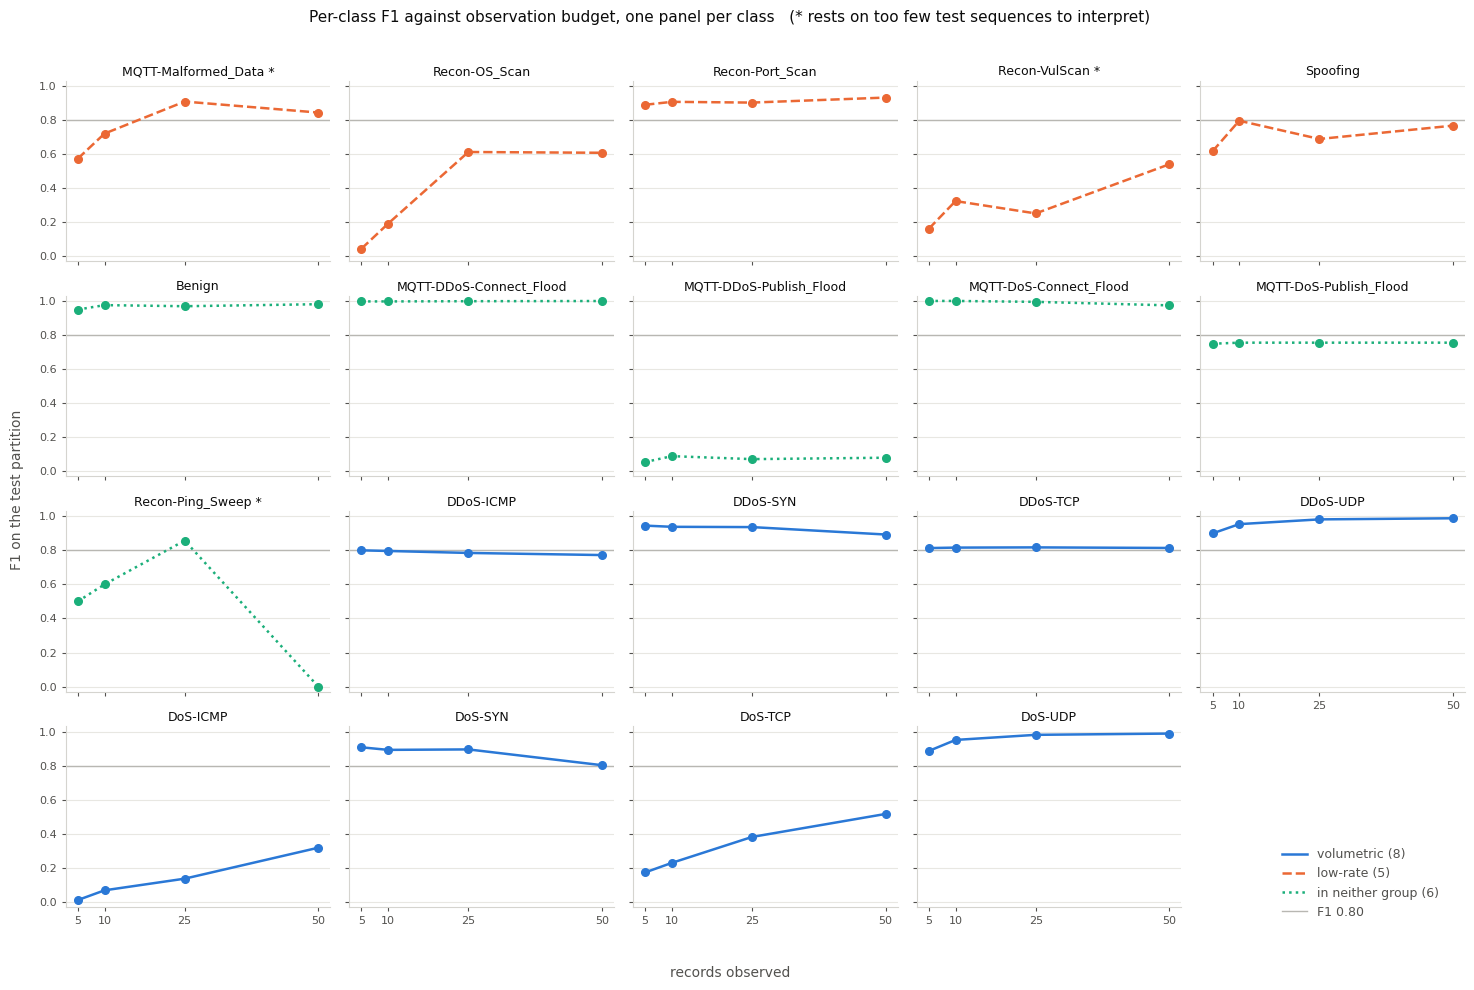

In [17]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

GROUP_STYLE = {
    "volumetric": {"color": "#2a78d6", "linestyle": "-"},
    "low-rate": {"color": "#eb6834", "linestyle": "--"},
    "neither": {"color": "#1baf7a", "linestyle": ":"},
}
INK, MUTED = "#0b0b0b", "#52514e"

ordered = curve.sort_values(["group", "class"]).reset_index(drop=True)
rows, columns = 4, 5
figure, axes = plt.subplots(rows, columns, figsize=(15, 10), sharex=True, sharey=True)
flat = axes.ravel()

for position, record in ordered.iterrows():
    axis = flat[position]
    style = GROUP_STYLE[record["group"]]
    axis.axhline(F1_TARGET, color="#b8b7b2", linewidth=1.0, zorder=1)
    axis.plot(
        list(BUDGETS),
        [record[c] for c in BUDGET_COLUMNS],
        marker="o", markersize=5.5, linewidth=1.8, zorder=3,
        color=style["color"], linestyle=style["linestyle"],
    )
    title = record["class"] + (" *" if record["thin"] else "")
    axis.set_title(title, fontsize=9, color=INK, pad=4)
    axis.set_ylim(-0.03, 1.03)
    axis.set_xticks(list(BUDGETS))
    axis.tick_params(labelsize=8, colors=MUTED, length=3)
    axis.grid(axis="y", color="#e8e7e2", linewidth=0.8)
    axis.set_axisbelow(True)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color("#d5d4cf")

for axis in flat[len(ordered):]:
    axis.set_visible(False)

# The grid is wider than the number of classes, so the bottom row is short and the
# columns it does not reach would lose their tick labels to sharex. Each column
# gets them back on its own lowest panel.
for column in range(columns):
    visible = [row for row in range(rows) if axes[row, column].get_visible()]
    if visible:
        axes[max(visible), column].tick_params(labelbottom=True)

handles = [
    Line2D([], [], linewidth=1.8, **GROUP_STYLE[g], label=label)
    for g, label in (
        ("volumetric", f"volumetric ({len(VOLUMETRIC)})"),
        ("low-rate", f"low-rate ({len(LOW_RATE)})"),
        ("neither", f"in neither group ({len(ordered) - len(VOLUMETRIC) - len(LOW_RATE)})"),
    )
]
handles.append(
    Line2D([], [], color="#b8b7b2", linewidth=1.0, label=f"F1 {F1_TARGET:.2f}")
)
figure.legend(
    handles=handles, loc="lower right", bbox_to_anchor=(0.98, 0.06),
    frameon=False, fontsize=9, labelcolor=MUTED,
)
figure.supxlabel("records observed", fontsize=10, color=MUTED)
figure.supylabel("F1 on the test partition", fontsize=10, color=MUTED)
figure.suptitle(
    "Per-class F1 against observation budget, one panel per class"
    "   (* rests on too few test sequences to interpret)",
    fontsize=11, color=INK,
)
figure.tight_layout(rect=(0.01, 0.02, 1, 0.97))

FIGURE_DIR = OUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_PATH = FIGURE_DIR / "NB08_learning_curves.png"
figure.savefig(FIGURE_PATH, dpi=200, facecolor="white")
print(f"written to {FIGURE_PATH}")
plt.show()


## Records observed to reach the threshold

This is the measurement H1 is stated in terms of: how many observed records each class
needs before it reaches F1 0.80, compared as the median of the low-rate group against the
median of the volumetric group, with the claim that low-rate classes need at least twice
as many.

Two things about the measurement have to be settled before it is made, and both are fixed
in the pre-registration rather than decided here.

The first is what to do with a class that never reaches 0.80. It has no value on this
scale. Fifty records is where the grid stops, not where the class stops needing records,
and writing 50 for a class that scored 0.31 there would put a number in the table that the
experiment did not measure. Those classes are recorded as right-censored and reported as
"> 50", and nothing is imputed for them.

The second is what a median means when some of the values are censored. A median needs
only the value at the middle position, not the values above it, so if that middle value is
uncensored the median is a real number regardless of how many classes above it never
reached the threshold. If the middle value is itself censored, the median is not determined
and is reported as not reached within fifty records. The group here with an even number of
classes needs both middle values, since its median is their average. The twofold comparison
is evaluated only when both group medians are determinate, and when either is not, what is
reported is the direction of the difference with the censored classes and the ceiling
named.


In [18]:
def records_to_threshold(per_class_by_budget, label, target=F1_TARGET):
    """The smallest budget at which this class reaches `target`, or censored."""
    for k in BUDGETS:
        if float(per_class_by_budget[k][label]) >= target:
            return k, False
    return None, True


PER_CLASS_BY_BUDGET = {k: BY_BUDGET[k]["metrics"]["per_class_f1"] for k in BUDGETS}

threshold_rows = []
for label in CLASSES:
    reached, censored = records_to_threshold(PER_CLASS_BY_BUDGET, label)
    scores = [float(PER_CLASS_BY_BUDGET[k][label]) for k in BUDGETS]
    threshold_rows.append(
        {
            "class": label,
            "group": (
                "volumetric" if label in VOLUMETRIC
                else "low-rate" if label in LOW_RATE else "neither"
            ),
            "records_to_f1_target": reached,
            "reported_as": "> 50" if censored else str(reached),
            "censored": censored,
            "best_f1": max(scores),
            "f1_at_50": scores[-1],
            "reaches_then_falls": bool(
                not censored and reached is not None and scores[-1] < F1_TARGET
            ),
            "thin": label in set(TOO_FEW_SEQUENCES) | set(THIN_BUT_KEPT),
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
for column in ("best_f1", "f1_at_50"):
    if not pd.api.types.is_numeric_dtype(threshold_table[column]):
        raise TypeError(f"{column} came out as {threshold_table[column].dtype}, not numeric")

print(f"smallest budget at which each class reaches F1 {F1_TARGET:.2f}")
print(threshold_table.sort_values(["group", "censored", "best_f1"])
      [["class", "group", "reported_as", "best_f1", "f1_at_50", "reaches_then_falls", "thin"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print(f"{int(threshold_table['censored'].sum())} of {len(CLASSES)} classes do not reach "
      f"F1 {F1_TARGET:.2f} within {FULL_BUDGET} records")
crossers = threshold_table[threshold_table["reaches_then_falls"]]
if len(crossers):
    print(f"reached the threshold at some budget and sat below it at {FULL_BUDGET}: "
          + ", ".join(crossers["class"]))
    print("  recorded at the smallest budget that reached it, which is what the metric asks for")


smallest budget at which each class reaches F1 0.80
                  class      group reported_as  best_f1  f1_at_50  reaches_then_falls  thin
    MQTT-Malformed_Data   low-rate          25   0.9067    0.8421               False  True
        Recon-Port_Scan   low-rate           5   0.9301    0.9301               False False
          Recon-VulScan   low-rate        > 50   0.5385    0.5385               False  True
          Recon-OS_Scan   low-rate        > 50   0.6105    0.6061               False False
               Spoofing   low-rate        > 50   0.7941    0.7653               False False
       Recon-Ping_Sweep    neither          25   0.8571    0.0000                True  True
                 Benign    neither           5   0.9808    0.9808               False False
MQTT-DDoS-Connect_Flood    neither           5   0.9996    0.9996               False False
 MQTT-DoS-Connect_Flood    neither           5   1.0000    0.9741               False False
MQTT-DDoS-Publish_Flood    n

In [19]:
def group_median(values):
    """The median of a group holding censored values, and whether it is determined.

    Censored values are known to be larger than every uncensored one, since they are
    classes that had not reached the threshold at the largest budget on the grid. They
    therefore sort to the top, and the position of the middle value is known even though
    its size is not. If the middle value is uncensored the median is that number. If it
    is censored, the median is somewhere above the grid and no number is available.
    """
    order = sorted(values, key=lambda v: (v is None, v if v is not None else 0))
    n = len(order)
    if n == 0:
        return None, False, "no classes in the group"
    if n % 2 == 1:
        middle = order[n // 2]
        if middle is None:
            return None, False, f"the value at the median position is censored above {FULL_BUDGET}"
        return float(middle), True, f"the {n // 2 + 1}th of {n} values"
    lower, upper = order[n // 2 - 1], order[n // 2]
    if lower is None or upper is None:
        return None, False, (
            f"an even group of {n}, so the median is the mean of the two middle values and at "
            f"least one of them is censored above {FULL_BUDGET}"
        )
    return float((lower + upper) / 2), True, f"the mean of the {n // 2}th and {n // 2 + 1}th of {n}"


GROUPS = {"low-rate": LOW_RATE, "volumetric": VOLUMETRIC}
medians = {}
for name, members in GROUPS.items():
    values = [
        threshold_table.set_index("class").loc[label, "records_to_f1_target"] for label in members
    ]
    values = [None if pd.isna(v) else int(v) for v in values]
    value, determinate, how = group_median(values)
    censored_here = [label for label, v in zip(members, values) if v is None]
    medians[name] = {
        "members": list(members),
        "values": values,
        "median": value,
        "determinate": determinate,
        "how": how,
        "censored": censored_here,
    }
    shown = ", ".join(
        f"{label} {'> ' + str(FULL_BUDGET) if v is None else v}" for label, v in zip(members, values)
    )
    print(f"{name} ({len(members)} classes): {shown}")
    print(f"  median: {value if determinate else f'not reached within {FULL_BUDGET} records'}"
          f"   [{how}]")
    if censored_here:
        print(f"  censored: {', '.join(censored_here)}")
    print()

low, vol = medians["low-rate"], medians["volumetric"]
print("H1: the median records low-rate classes need to reach F1 0.80 is at least twice the "
      "volumetric median")
print()
if low["determinate"] and vol["determinate"]:
    ratio = low["median"] / vol["median"] if vol["median"] else float("inf")
    print(f"  both medians are determinate: low-rate {low['median']:g}, volumetric "
          f"{vol['median']:g}, ratio {ratio:.2f}")
    print(f"  at least twofold: {'yes' if ratio >= 2 else 'no'}")
else:
    undetermined = [n for n in ("low-rate", "volumetric") if not medians[n]["determinate"]]
    print(f"  the {' and '.join(undetermined)} median is not determinate, so the twofold "
          "comparison is not evaluated.")
    print("  What is reported instead is the direction of the difference.")
    print()
    for name in ("low-rate", "volumetric"):
        entry = medians[name]
        stated = entry["median"] if entry["determinate"] else f"> {FULL_BUDGET}"
        print(f"    {name:<11} median {stated}, {len(entry['censored'])} of "
              f"{len(entry['members'])} classes censored"
              + (f": {', '.join(entry['censored'])}" if entry["censored"] else ""))
    if low["determinate"] != vol["determinate"]:
        needs_more = "low-rate" if not low["determinate"] else "volumetric"
        print()
        print(f"    Direction: the {needs_more} median sits above the budget ceiling of "
              f"{FULL_BUDGET} records while the other does not, so {needs_more} classes "
              f"require more observed records. The size of the difference is not measurable "
              f"on a grid that stops at {FULL_BUDGET}.")
    elif not low["determinate"] and not vol["determinate"]:
        print()
        print(f"    Direction: neither median is reached within {FULL_BUDGET} records, so "
              "no direction is available from the medians either.")
print()
print(f"Recon-Ping_Sweep is outside both groups and its figure is reported without being "
      f"interpreted: reported_as "
      f"{threshold_table.set_index('class').loc['Recon-Ping_Sweep', 'reported_as']}, "
      f"best F1 {threshold_table.set_index('class').loc['Recon-Ping_Sweep', 'best_f1']:.4f} "
      f"on {SEQUENCES['test']['Recon-Ping_Sweep']} test sequences.")


low-rate (5 classes): Recon-OS_Scan > 50, Recon-Port_Scan 5, Recon-VulScan > 50, Spoofing > 50, MQTT-Malformed_Data 25
  median: not reached within 50 records   [the value at the median position is censored above 50]
  censored: Recon-OS_Scan, Recon-VulScan, Spoofing

volumetric (8 classes): DDoS-ICMP > 50, DDoS-SYN 5, DDoS-TCP 5, DDoS-UDP 5, DoS-ICMP > 50, DoS-SYN 5, DoS-TCP > 50, DoS-UDP 5
  median: 5.0   [the mean of the 4th and 5th of 8]
  censored: DDoS-ICMP, DoS-ICMP, DoS-TCP

H1: the median records low-rate classes need to reach F1 0.80 is at least twice the volumetric median

  the low-rate median is not determinate, so the twofold comparison is not evaluated.
  What is reported instead is the direction of the difference.

    low-rate    median > 50, 3 of 5 classes censored: Recon-OS_Scan, Recon-VulScan, Spoofing
    volumetric  median 5.0, 3 of 8 classes censored: DDoS-ICMP, DoS-ICMP, DoS-TCP

    Direction: the low-rate median sits above the budget ceiling of 50 records whil

## Where each class stops improving

This is an additional analysis and not a hypothesis test. Nothing in the pre-registration
sets a threshold on it and nothing below is a pass or a fail.

The previous analysis asks when a class reaches a fixed level, which is a question about
whether the class is usable. This one asks a different question: when does a class stop
getting better, whatever level it got to. A class that scores 0.31 at every budget has
learned everything the budget can teach it by the fifth record, and that is worth knowing
even though it never becomes detectable. The measurement is the smallest budget at which a
class comes within a tolerance of its own best score across the four budgets, so each class
is measured against itself.

The tolerance is 0.02. Reading a curve as flat once it is within a small fixed margin of
its own maximum is the convention used in the early-detection and learning-curve work this
measurement follows, in Silvey and Liu (JMIR, 2024) and in Mohr et al. (arXiv:2201.12150),
and the value is fixed here before the curves are read rather than tuned to them.


In [20]:
saturation_rows = []
for label in CLASSES:
    scores = {k: float(PER_CLASS_BY_BUDGET[k][label]) for k in BUDGETS}
    best = max(scores.values())
    reached = next(k for k in BUDGETS if scores[k] >= best - SATURATION_EPSILON)
    saturation_rows.append(
        {
            "class": label,
            "group": (
                "volumetric" if label in VOLUMETRIC
                else "low-rate" if label in LOW_RATE else "neither"
            ),
            "best_f1": best,
            "best_at_k": min(k for k in BUDGETS if scores[k] == best),
            "saturates_at_k": reached,
            "f1_there": scores[reached],
            "usable_there": bool(scores[reached] >= F1_TARGET),
            "thin": label in set(TOO_FEW_SEQUENCES) | set(THIN_BUT_KEPT),
        }
    )

saturation = pd.DataFrame(saturation_rows)
for column in ("best_f1", "best_at_k", "saturates_at_k", "f1_there"):
    if not pd.api.types.is_numeric_dtype(saturation[column]):
        raise TypeError(f"{column} came out as {saturation[column].dtype}, not numeric")

print(f"smallest budget within {SATURATION_EPSILON:.2f} of the class's own best score")
print(saturation.sort_values(["saturates_at_k", "group", "class"])
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("how many classes stop improving at each budget")
spread = saturation.groupby(["saturates_at_k", "group"]).size().unstack(fill_value=0)
print(spread.to_string())
print()
flat_early = saturation[(saturation["saturates_at_k"] == BUDGETS[0]) & ~saturation["usable_there"]]
print(f"{len(flat_early)} class(es) stop improving at {BUDGETS[0]} records while still below "
      f"F1 {F1_TARGET:.2f}"
      + (f": {', '.join(flat_early['class'])}" if len(flat_early) else ""))
print("  For these, a longer window is not what is missing.")


smallest budget within 0.02 of the class's own best score
                  class      group  best_f1  best_at_k  saturates_at_k  f1_there  usable_there  thin
MQTT-DDoS-Connect_Flood    neither   0.9996         50               5    0.9973          True False
 MQTT-DoS-Connect_Flood    neither   1.0000          5               5    1.0000          True False
 MQTT-DoS-Publish_Flood    neither   0.7551         10               5    0.7488         False False
              DDoS-ICMP volumetric   0.7998          5               5    0.7998         False False
               DDoS-SYN volumetric   0.9449          5               5    0.9449          True False
               DDoS-TCP volumetric   0.8172         25               5    0.8132          True False
                DoS-SYN volumetric   0.9073          5               5    0.9073          True False
               Spoofing   low-rate   0.7941         10              10    0.7941         False False
                 Benign    neithe

## What the seed alone moves

Five runs at the full budget, identical in every respect but the seed. Nothing here is a
comparison between configurations. What it measures is how much a number moves when
nothing that matters has changed, which is the scale every other difference in this project
has to be read against.

The standard deviation is over five runs, so it is itself a rough estimate, and it is
reported with the five values beside it rather than on its own.

DoS-ICMP is reported separately. Under the sequence model at seed 42 it scored far below
what a single-record model scored on the same class, and whether that is a property of the
model or a property of that one seed has been recorded in this project as unresolved. Five
seeds can answer one narrow version of the question, which is whether the low value repeats.
They cannot say what caused it. What is stated below is the five values and nothing beyond
them.


In [21]:
seed_macro = pd.DataFrame(
    [
        {
            "seed": s,
            "run_id": BY_SEED[s]["config"]["run_id"],
            "macro_f1": float(BY_SEED[s]["metrics"]["macro_f1"]),
            "weighted_f1": float(BY_SEED[s]["metrics"]["weighted_f1"]),
            "accuracy": float(BY_SEED[s]["metrics"]["accuracy"]),
        }
        for s in ALL_SEEDS
    ]
)
for column in ("macro_f1", "weighted_f1", "accuracy"):
    if not pd.api.types.is_numeric_dtype(seed_macro[column]):
        raise TypeError(f"{column} came out as {seed_macro[column].dtype}, not numeric")

print(f"the five runs at budget {FULL_BUDGET}, one per seed")
print(seed_macro.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
for column in ("macro_f1", "weighted_f1", "accuracy"):
    values = seed_macro[column].to_numpy()
    print(f"{column:<12} mean {values.mean():.4f}, sd {values.std(ddof=1):.4f}, "
          f"range {values.min():.4f} to {values.max():.4f}, spread {values.max() - values.min():.4f}")
MACRO_SD = float(seed_macro["macro_f1"].std(ddof=1))
MACRO_MEAN = float(seed_macro["macro_f1"].mean())

per_class_seeds = pd.DataFrame(
    {
        "class": CLASSES,
        **{
            f"seed_{s}": [float(BY_SEED[s]["metrics"]["per_class_f1"][c]) for c in CLASSES]
            for s in ALL_SEEDS
        },
    }
)
seed_columns = [f"seed_{s}" for s in ALL_SEEDS]
per_class_seeds["mean"] = per_class_seeds[seed_columns].mean(axis=1)
per_class_seeds["sd"] = per_class_seeds[seed_columns].std(axis=1, ddof=1)
per_class_seeds["spread"] = (
    per_class_seeds[seed_columns].max(axis=1) - per_class_seeds[seed_columns].min(axis=1)
)
per_class_seeds["group"] = [
    "volumetric" if c in VOLUMETRIC else "low-rate" if c in LOW_RATE else "neither"
    for c in CLASSES
]
for column in [*seed_columns, "mean", "sd", "spread"]:
    if not pd.api.types.is_numeric_dtype(per_class_seeds[column]):
        raise TypeError(f"{column} came out as {per_class_seeds[column].dtype}, not numeric")

print()
print(f"per-class F1 across the five seeds at budget {FULL_BUDGET}, widest spread first")
print(per_class_seeds.sort_values("spread", ascending=False)
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print(f"macro-F1 across seeds: {MACRO_MEAN:.4f} plus or minus {MACRO_SD:.4f}")
print(f"a per-class difference smaller than that class's own spread across seeds is not "
      f"distinguishable from the seed")


the five runs at budget 50, one per seed
 seed                    run_id  macro_f1  weighted_f1  accuracy
   42 sequence_cnn_lstm_19class    0.7138       0.8064    0.8197
   43          sequence_seed_43    0.7552       0.8300    0.8441
   44          sequence_seed_44    0.7652       0.8045    0.8141
   45          sequence_seed_45    0.7377       0.7980    0.8143
   46          sequence_seed_46    0.7144       0.8208    0.8374

macro_f1     mean 0.7373, sd 0.0233, range 0.7138 to 0.7652, spread 0.0514
weighted_f1  mean 0.8119, sd 0.0131, range 0.7980 to 0.8300, spread 0.0321
accuracy     mean 0.8259, sd 0.0139, range 0.8141 to 0.8441, spread 0.0300

per-class F1 across the five seeds at budget 50, widest spread first
                  class  seed_42  seed_43  seed_44  seed_45  seed_46   mean     sd  spread      group
       Recon-Ping_Sweep   0.0000   0.4000   0.8000   0.6667   0.0000 0.3733 0.3700  0.8000    neither
          Recon-OS_Scan   0.6061   0.6765   0.8049   0.6195   0.6493 

In [22]:
row = per_class_seeds.set_index("class").loc["DoS-ICMP"]
DOS_ICMP_VALUES = np.array([row[c] for c in seed_columns], dtype="float64")
values = DOS_ICMP_VALUES

print("DoS-ICMP at budget 50, all five seeds")
for s, value in zip(ALL_SEEDS, values):
    print(f"  seed {s}: {value:.4f}")
print()
print(f"  mean {values.mean():.4f}, sd {values.std(ddof=1):.4f}, "
      f"range {values.min():.4f} to {values.max():.4f}")
print(f"  seeds at or above F1 {F1_TARGET:.2f}: {int((values >= F1_TARGET).sum())} of {len(values)}")
print(f"  seeds at or above F1 0.50: {int((values >= 0.50).sum())} of {len(values)}")
print()
print("What these five numbers say is whether the low value at seed 42 repeats at other")
print("seeds. They do not say what produces it. No run in this notebook was designed to")
print("diagnose the cause, and none of them does.")


DoS-ICMP at budget 50, all five seeds
  seed 42: 0.3178
  seed 43: 0.3099
  seed 44: 0.3450
  seed 45: 0.2690
  seed 46: 0.2938

  mean 0.3071, sd 0.0282, range 0.2690 to 0.3450
  seeds at or above F1 0.80: 0 of 5
  seeds at or above F1 0.50: 0 of 5

What these five numbers say is whether the low value at seed 42 repeats at other
seeds. They do not say what produces it. No run in this notebook was designed to
diagnose the cause, and none of them does.


## Whether the differences are larger than chance

McNemar's test compares two models item by item. It looks only at the items the two
disagree on: the ones the first got right and the second got wrong, and the ones the other
way round. If the two models were equally good those two counts would be two halves of the
same coin, and the test asks how far from an even split the observed counts fall. Items
both got right and items both got wrong carry no information about which is better and are
not in the test at all.

That is why it can only be run between runs scored on the same items. Two of those sets
exist here. The four budgets are four models scored on the same 49,159 test windows, and
the five class-balancing runs from earlier in this project are scored on those same
windows against the same parent, so both sets pair item to item.

Eleven tests are computed. At alpha 0.05 each on its own, the chance of at least one false
positive among eleven independent tests is over forty percent, so the p-values are
corrected. Holm-Bonferroni is used, which ranks the p-values, applies the strictest
multiplier to the smallest and a weaker one to each after it, and holds the chance of any
false positive across the family at alpha. The correction is applied within each set,
because the two sets answer different questions and are read separately. The stricter
correction over all eleven at once is printed in the same table, so a reader who prefers
to treat them as one family can read that column instead.


In [23]:
def load_predictions(run_id, subdirs):
    """Predictions of a run written elsewhere, checked against this notebook's labels."""
    files = find_run_files(subdirs)
    for name in ("y_true.npy", "y_pred.npy"):
        if files[name] is None:
            raise FileNotFoundError(f"{run_id} has no {name}. Looked in {[str(d) for d in subdirs]}")
    y_true = np.load(files["y_true.npy"]).astype("int64")
    y_pred = np.load(files["y_pred.npy"]).astype("int64")
    if not np.array_equal(y_true, DATA["y_test"]):
        raise ValueError(
            f"{run_id} was scored on different labels than this notebook loaded, so it cannot "
            "be paired against anything here"
        )
    return y_pred


for name in INTERVENTIONS:
    PREDICTIONS[name] = load_predictions(
        name, [REPO_ROOT / "results" / "NB07" / name, ARTIFACTS / "NB07" / name]
    )

BUDGET_RUN_ID = {k: BY_BUDGET[k]["config"]["run_id"] for k in BUDGETS}

budget_pairs = [
    sg.mcnemar(
        DATA["y_test"],
        PREDICTIONS[BUDGET_RUN_ID[a]],
        PREDICTIONS[BUDGET_RUN_ID[b]],
        name_a=f"k{a}",
        name_b=f"k{b}",
    )
    for i, a in enumerate(BUDGETS)
    for b in BUDGETS[i + 1:]
]
intervention_pairs = [
    sg.mcnemar(
        DATA["y_test"], PREDICTIONS[PARENT_RUN], PREDICTIONS[name],
        name_a=PARENT_RUN, name_b=name,
    )
    for name in INTERVENTIONS
]

families = [
    *sg.compare_family(budget_pairs, alpha=ALPHA, family="budget against budget"),
    *sg.compare_family(intervention_pairs, alpha=ALPHA, family="parent against intervention"),
]
across_all, reject_all = sg.holm_bonferroni([row["p_value"] for row in families], alpha=ALPHA)
for row, value, flag in zip(families, across_all, reject_all):
    row["holm_p_all_11"] = float(value)
    row["significant_all_11"] = bool(flag)

mcnemar_table = pd.DataFrame(families)[
    [
        "family", "a", "b", "accuracy_a", "accuracy_b", "only_a_correct", "only_b_correct",
        "discordant", "statistic", "p_value", "holm_p", "significant_at_alpha",
        "holm_p_all_11", "favours", "method",
    ]
]
for column in ("accuracy_a", "accuracy_b", "only_a_correct", "only_b_correct", "discordant",
               "statistic", "p_value", "holm_p", "holm_p_all_11"):
    if not pd.api.types.is_numeric_dtype(mcnemar_table[column]):
        raise TypeError(f"{column} came out as {mcnemar_table[column].dtype}, not numeric")

print(f"McNemar on {N_TEST:,} paired test windows, Holm-Bonferroni at alpha {ALPHA}")
print(f"corrected within each family of {len(budget_pairs)} and {len(intervention_pairs)}, "
      f"and again across all {len(families)}")
print()
print(mcnemar_table.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
print()
for family in ("budget against budget", "parent against intervention"):
    part = mcnemar_table[mcnemar_table["family"] == family]
    print(f"{family}: {int(part['significant_at_alpha'].sum())} of {len(part)} significant "
          f"after correction within the family, "
          f"{int(part['significant_all_11'].sum() if 'significant_all_11' in part else 0)} "
          f"of {len(part)} under the correction across all {len(families)}")


McNemar on 49,159 paired test windows, Holm-Bonferroni at alpha 0.05
corrected within each family of 6 and 5, and again across all 11

                     family                         a                   b  accuracy_a  accuracy_b  only_a_correct  only_b_correct  discordant  statistic     p_value      holm_p  significant_at_alpha  holm_p_all_11                   favours                                method
      budget against budget                        k5                 k10    0.803658    0.818833             872            1618        2490    222.902 2.10614e-50 1.05307e-49                  True    1.68491e-49                       k10 chi-square with continuity correction
      budget against budget                        k5                 k25    0.803658    0.826461            1503            2624        4127     303.95  4.5426e-68 2.72556e-67                  True     4.5426e-67                       k25 chi-square with continuity correction
      budget against budget    

One comparison that might be expected here is not computed, and the reason is not that it
came out badly.

H2 names the published single-record CNN as its comparator. That run and this one cannot
be compared by McNemar, because McNemar pairs item with item and there are no pairs to
make. The sequence model is scored on 49,159 windows and the published run on 1,614,182
single records, so the two are not the same number of things and they are not the same kind
of thing: one item here is fifty records, one item there is one record. They are also drawn
from different test partitions, the shipped within-capture split against the capture-disjoint
split built in this project, so even at matching units the two would not be scoring the same
traffic.

No substitute test is computed in place of it. A test invented to fill the gap would be a
test of something other than what H2 claims, and reporting it would be worse than reporting
nothing. What H2 rests on is stated where H2 is stated: the cross-seed mean and standard
deviation measured above, and the per-class movement on the class set fixed in the
pre-registration, both of which are properties of runs this project executed rather than
of a pairing that does not exist.


The block below is the entry for the results ledger, printed rather than written, so that
what goes into the file is read once before it goes in.


In [24]:
dirty_note = " (working tree dirty)" if GIT_DIRTY else ""
trained_ids = ", ".join(run["config"]["run_id"] for run in RUNS.values())
seed_list = ", ".join(str(s) for s in ALL_SEEDS)
budget_list = ", ".join(str(k) for k in BUDGETS)
macro_line = ", ".join(f"k{k} {BY_BUDGET[k]['metrics']['macro_f1']:.4f}" for k in BUDGETS)
detected_line = ", ".join(
    f"k{k} " + str(sum(v >= F1_TARGET for v in BY_BUDGET[k]["metrics"]["per_class_f1"].values()))
    for k in BUDGETS
)
dos_icmp_line = ", ".join(f"{v:.4f}" for v in DOS_ICMP_VALUES)
low_state = f"{low['median']:g}" if low["determinate"] else f"not reached within {FULL_BUDGET}"
vol_state = f"{vol['median']:g}" if vol["determinate"] else f"not reached within {FULL_BUDGET}"
twofold_state = (
    "evaluated"
    if low["determinate"] and vol["determinate"]
    else "not evaluated, at least one median is not determinate; direction reported instead"
)
budget_family = mcnemar_table[mcnemar_table["family"] == "budget against budget"]
intervention_family = mcnemar_table[mcnemar_table["family"] == "parent against intervention"]
budget_significant = int(budget_family["significant_at_alpha"].sum())
intervention_significant = int(intervention_family["significant_at_alpha"].sum())
saturating_early = int((saturation["saturates_at_k"] == BUDGETS[0]).sum())
n_censored = int(threshold_table["censored"].sum())
n_parameters = int(inventory["parameters"].iloc[0])

entry = f"""
### NB08 — evaluation and significance ({RUN_DATE})

| field | value |
|---|---|
| notebook | {NOTEBOOK} |
| git sha | {GIT_SHA}{dirty_note} |
| seeds | {seed_list} |
| parent | {PARENT_RUN}, unchanged and not retrained |
| runs trained here | {len(RUNS)}: {trained_ids} |
| budgets | k in {budget_list} records, taken as prefixes of the NB04 windows at window {WINDOW} stride {STRIDE} |
| test items | {N_TEST:,} windows, identical across every run, asserted |
| parameters | {n_parameters:,} in every run, unchanged by the budget |
| macro F1 by budget | {macro_line} |
| classes at F1 {F1_TARGET:.2f} by budget | {detected_line} |
| censored at k={FULL_BUDGET} | {n_censored} of {len(CLASSES)} classes, reported as "> {FULL_BUDGET}" and never as {FULL_BUDGET} |
| H1 median, low-rate | {low_state} ({len(low["censored"])} of {len(low["members"])} censored) |
| H1 median, volumetric | {vol_state} ({len(vol["censored"])} of {len(vol["members"])} censored) |
| H1 twofold comparison | {twofold_state} |
| saturation, additional analysis | epsilon {SATURATION_EPSILON:.2f}, classes stopping at k={BUDGETS[0]}: {saturating_early} of {len(CLASSES)} |
| cross-seed macro F1 | {MACRO_MEAN:.4f} plus or minus {MACRO_SD:.4f} over {len(ALL_SEEDS)} seeds at k={FULL_BUDGET} |
| DoS-ICMP across seeds | {dos_icmp_line} |
| McNemar | {len(families)} paired tests, Holm-Bonferroni at alpha {ALPHA}: {budget_significant} of {len(budget_family)} budget pairs and {intervention_significant} of {len(intervention_family)} intervention pairs significant within their family |
| not computed | McNemar against published_cnn_19class. Different units and different splits, so no item-level pairing exists. No substitute test was computed |
| label encoding | {CODE_DTYPE} codes into label_map.json, written beside the runs |
| artifacts | {OUT_DIR} |
| status | H1 measurement and cross-seed variation; the saturation analysis is additional and carries no threshold |
"""

print(entry)



### NB08 — evaluation and significance (2026-08-10)

| field | value |
|---|---|
| notebook | AG_PRAXIS_NB08_evaluation_and_significance.ipynb |
| git sha | d193464 |
| seeds | 42, 43, 44, 45, 46 |
| parent | sequence_cnn_lstm_19class, unchanged and not retrained |
| runs trained here | 7: sequence_budget_05, sequence_budget_10, sequence_budget_25, sequence_seed_43, sequence_seed_44, sequence_seed_45, sequence_seed_46 |
| budgets | k in 5, 10, 25, 50 records, taken as prefixes of the NB04 windows at window 50 stride 25 |
| test items | 49,159 windows, identical across every run, asserted |
| parameters | 214,227 in every run, unchanged by the budget |
| macro F1 by budget | k5 0.6295, k10 0.6837, k25 0.7323, k50 0.7138 |
| classes at F1 0.80 by budget | k5 9, k10 9, k25 11, k50 10 |
| censored at k=50 | 8 of 19 classes, reported as "> 50" and never as 50 |
| H1 median, low-rate | not reached within 50 (3 of 5 censored) |
| H1 median, volumetric | 5 (3 of 8 censored) |
| H1 twofold com